### Building Agentic Document Understanding

In [1]:
from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from typing import List, Dict, Any

#### 1. Text Extraction with PaddleOCR + LayoutLM Ordering

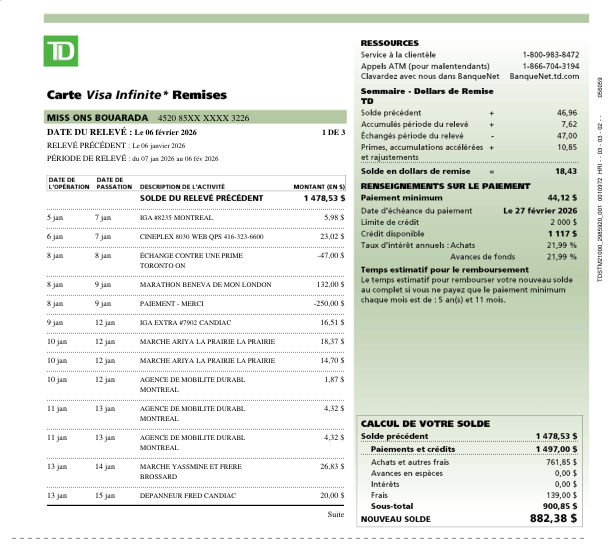

In [13]:
from paddleocr import PaddleOCR
# Initialize once per kernel to avoid PDX reinit errors
if "ocr" not in globals():
    ocr = PaddleOCR(lang="en", enable_mkldnn=False,  # prevents MKLDNN/PIR crash
                    )
    
# Load image
image_path = "files/page_0.png"
display(Image.open(image_path))

In [14]:
# Run OCR 
result = ocr.predict(image_path)
page = result[0]

In [15]:
page.keys()

dict_keys(['input_path', 'page_index', 'doc_preprocessor_res', 'dt_polys', 'model_settings', 'text_det_params', 'text_type', 'text_rec_score_thresh', 'return_word_box', 'rec_texts', 'rec_scores', 'rec_polys', 'vis_fonts', 'textline_orientation_angles', 'rec_boxes'])

In [16]:
texts = page['rec_texts']      # recognized text strings
scores = page['rec_scores']    # confidence scores
boxes = page['rec_polys']      # bounding box coordinates

In [17]:
for text, score, box in list(zip(texts, scores, boxes))[:20]:
    coords = box.astype(int).tolist()
    print(f"{text:50} | {score:.3f} | {coords}")

D                                                  | 0.917 | [[15, 31], [35, 31], [35, 50], [15, 50]]
RESSOURCES                                         | 0.999 | [[355, 26], [423, 24], [424, 38], [356, 40]]
Service a la clientele                             | 0.971 | [[356, 39], [443, 39], [443, 52], [356, 52]]
1-800-983-8472                                     | 1.000 | [[536, 39], [602, 39], [602, 50], [536, 50]]
Appels ATM (pour malentendants)                    | 0.997 | [[355, 50], [502, 49], [502, 63], [355, 64]]
1-866-704-3194                                     | 1.000 | [[536, 50], [603, 50], [603, 61], [536, 61]]
Clavardez avec nous dans BanqueNet                 | 0.986 | [[357, 62], [513, 62], [513, 72], [357, 72]]
BanqueNet.td.com                                   | 0.997 | [[520, 60], [604, 60], [604, 73], [520, 73]]
Carte Visa Infinite* Remises                       | 0.985 | [[5, 77], [213, 80], [213, 94], [5, 91]]
Semmaire - Dollars de Remise                       | 0

##### 1.2 OCR bounding boxes

In [18]:
processed_img = page['doc_preprocessor_res']['output_img']  # preprocessed image used for OCR
img_plot = processed_img.copy()
show_text = False

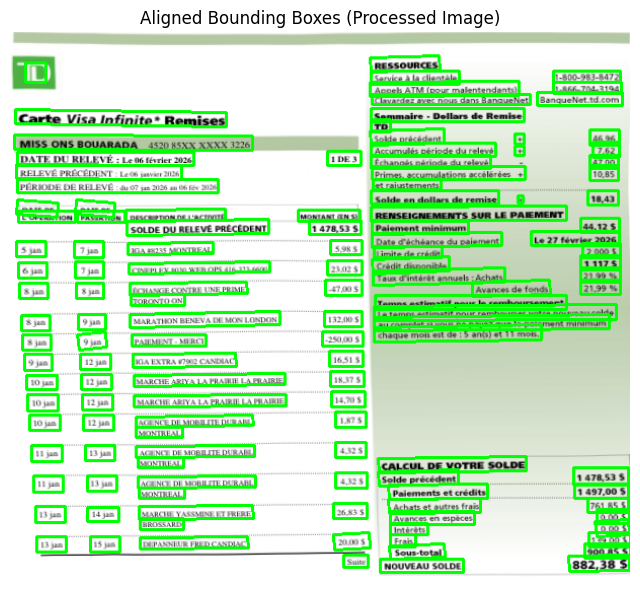

In [19]:


for text, box in zip(texts, boxes):
    pts = np.array(box, dtype=int)
    cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
    x, y = pts[0]
    if show_text:
        cv2.putText(img_plot, text, (x, y - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        
plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Aligned Bounding Boxes (Processed Image)")
plt.show()

##### 1.3. Structuring OCR Results with a Dataclass

In [20]:
@dataclass
class OCRRegion:
    text: str
    bbox: list
    confidence: float # [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]

    @property 
    def bbox_xyxy(self):
        """return bbox in [x_min, y_min, x_max, y_max] format"""
        x_coords = [point[0] for point in self.bbox]
        y_coords = [point[1] for point in self.bbox]
        return [min(x_coords), min(y_coords), max(x_coords), max(y_coords)]

In [21]:
ocr_regions: List[OCRRegion] = []
for text, score, box in zip(texts, scores, boxes):
    ocr_regions.append(OCRRegion(text=text, bbox=box.astype(int).tolist(), confidence=score))

len(ocr_regions) # number of text regions detected

130

##### 1.4. LayoutLM Reading Order